## Medical abstracts — T5 inference

Load a **fine-tuned T5** checkpoint and run predictions on validation or test splits. Align `base_dir` and checkpoint paths with where you saved the model from `T5_medicalAbstract_finetune.ipynb`.

In [ ]:
import re
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score, f1_score, precision_score,precision_recall_fscore_support, recall_score
from sklearn.metrics import classification_report,precision_recall_fscore_support, accuracy_score,precision_score, recall_score, f1_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from datasets import load_dataset,Dataset,concatenate_datasets
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from transformers import (
    T5Tokenizer,
    T5ForConditionalGeneration,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    AutoModelForSequenceClassification,
    EarlyStoppingCallback,
    DataCollatorWithPadding
)

#from datasets import Dataset
import torch

from torch.utils.data import DataLoader, WeightedRandomSampler, TensorDataset

In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
base_dir = colab_dir + "d266/FinalProject/"

Mounted at /content/gdrive/


## Load dataset

In [ ]:
# Define the label mapping
label_map = {
    1: "Neoplasms",
    2: "Digestive system diseases",
    3: "Nervous system diseases",
    4: "Cardiovascular diseases",
    5: "General pathological conditions",
}

In [ ]:
#train_df
val_df = pd.read_csv(base_dir+"medicalabstract_val.csv")
test_df = pd.read_csv(base_dir+"medicalabstract_test.csv")

In [ ]:
val_df

,Unnamed: 0,text,label
0,0,Rectal strictures: treatment with fluoroscopic...,2
1,1,Human tumor fluorouracil trapping: clinical co...,1
2,2,Elevated serum concentrations of IgE antibodie...,1
3,3,Severe cerebral and systemic necrotizing vascu...,3
4,4,The effects of dopamine on myocardial function...,4
...,...,...,...
2829,2829,Comparison of silent and symptomatic ischemia ...,4
2830,2830,Epidurography in premature infants. A caudal e...,5
2831,2831,Intrahepatic cholesterol stones: a rationale f...,2
2832,2832,Vulvar intraepithelial neoplasia. A clinicopat...,1


In [ ]:
label2id = {
    "Neoplasms": 0,
    "Digestive system diseases": 1,
    "Nervous system diseases": 2,
    "Cardiovascular diseases": 3,
    "General pathological conditions": 4,
}

id2label = {v: k for k, v in label2id.items()}

#train_ds = Dataset.from_pandas(train_df[["text","label"]], preserve_index=False)
val_ds   = Dataset.from_pandas(val_df[["text","label"]],   preserve_index=False)
test_ds  = Dataset.from_pandas(test_df[["text","label"]],  preserve_index=False)

In [ ]:

# CONFIGURATION

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Detect environment
if os.getenv("COLAB_RELEASE_TAG"):
    from google.colab import drive
    drive.mount('/content/gdrive/')
    colab_dir = "/content/gdrive/MyDrive/Colab Notebooks/"
    base_dir = colab_dir + "d266/FinalProject/"

    # For Drug Review dataset
    model_path = base_dir + "t5base_finetuned_medicalabstract"

    val_csv = pd.read_csv(base_dir+"medicalabstract_val.csv")
    test_csv = pd.read_csv(base_dir+"medicalabstract_test.csv")

    task_prefix = "Classify this review into rating 0-4: "

else:
    # Local or Kaggle
    base_dir = "./"

    # For Mental Health dataset
    model_path = base_dir + "t5base_finetuned_medicalabstract"
    val_csv = pd.read_csv(base_dir+"medicalabstract_val.csv")
    test_csv = pd.read_csv(base_dir+"medicalabstract_test.csv")

    task_prefix = "mental health classification: "

print(f"Model path: {model_path}")
print(f"Base directory: {base_dir}")

Using device: cuda
Drive already mounted at /content/gdrive/; to attempt to forcibly remount, call drive.mount("/content/gdrive/", force_remount=True).
Model path: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_medicalabstract
Base directory: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/


In [ ]:
val_csv

,Unnamed: 0,text,label
0,0,Rectal strictures: treatment with fluoroscopic...,2
1,1,Human tumor fluorouracil trapping: clinical co...,1
2,2,Elevated serum concentrations of IgE antibodie...,1
3,3,Severe cerebral and systemic necrotizing vascu...,3
4,4,The effects of dopamine on myocardial function...,4
...,...,...,...
2829,2829,Comparison of silent and symptomatic ischemia ...,4
2830,2830,Epidurography in premature infants. A caudal e...,5
2831,2831,Intrahepatic cholesterol stones: a rationale f...,2
2832,2832,Vulvar intraepithelial neoplasia. A clinicopat...,1


In [ ]:

print("Val split shape :",val_ds.shape)

print("test split shape :",test_ds.shape)

Val split shape : (2834, 2)
test split shape : (2770, 2)


In [ ]:
# Ensure the data has the right columns
if 'statement' in val_df.columns:
    val_df = val_df.rename(columns={'statement': 'text'})
    test_df = test_df.rename(columns={'statement': 'text'})

if 'status_combined' in val_df.columns:
    # For mental health dataset - convert to numeric label
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    val_df['label'] = le.fit_transform(val_df['status_combined']).astype(str)
    test_df['label'] = le.transform(test_df['status_combined']).astype(str)
    label_names = le.classes_
else:
    # For drug review dataset - label already numeric
    val_df['label'] = val_df['label'].astype(str)
    test_df['label'] = test_df['label'].astype(str)
    label_names = sorted(val_df['label'].unique())

print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")
print(f"Label distribution in validation:\n{val_df['label'].value_counts().sort_index()}")

# Create datasets
val_ds = Dataset.from_pandas(val_df[["text", "label"]])
test_ds = Dataset.from_pandas(test_df[["text", "label"]])


# LOAD MODEL AND TOKENIZER

print(f"\nLoading model from: {model_path}")
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path).to(device)
model.eval()

print(f"Model loaded successfully!")
print(f"Vocab size: {len(tokenizer)}")




Validation samples: 2834
Test samples: 2770
Label distribution in validation:
label
1    665
2    278
3    365
4    618
5    908
Name: count, dtype: int64

Loading model from: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/t5base_finetuned_medicalabstract
Model loaded successfully!
Vocab size: 32100

Tokenizing datasets...


Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2770 [00:00<?, ? examples/s]

In [ ]:
# TOKENIZATION

def preprocess_function(examples):
    """Preprocess examples for T5"""
    inputs = [task_prefix + text for text in examples["text"]]

    model_inputs = tokenizer(
        inputs,
        max_length=128,
        truncation=True,
        padding="max_length"
    )

    # Tokenize label
    with tokenizer.as_target_tokenizer():
        label = tokenizer(
            examples["label"],
            max_length=2,
            truncation=True,
            padding="max_length"
        )

    model_inputs["label"] = label["input_ids"]
    return model_inputs

print("\nTokenizing datasets...")
tokenized_val = val_ds.map(preprocess_function, batched=True, remove_columns=["text"])
tokenized_test = test_ds.map(preprocess_function, batched=True, remove_columns=["text"])

# EVALUATION FUNCTION

def evaluate_dataset(model, tokenizer, dataset, dataset_name, label_names, device, batch_size=16):

    print(f"\n{'='*70}")
    print(f"EVALUATING {dataset_name.upper()} SET")
    print(f"{'='*70}")

    model.eval()

    all_predictions = []
    all_true_label = []

    num_samples = len(dataset)
    print(f"Processing {num_samples} samples...")

    # Process in batches
    with torch.no_grad():
        for i in range(0, num_samples, batch_size):
            batch_end = min(i + batch_size, num_samples)
            batch_size_actual = batch_end - i

            # Get batch data
            batch_input_ids = torch.tensor([dataset[j]['input_ids'] for j in range(i, batch_end)]).to(device)
            batch_attention_mask = torch.tensor([dataset[j]['attention_mask'] for j in range(i, batch_end)]).to(device)
            batch_label = [dataset[j]['label'] for j in range(i, batch_end)]

            # Generate predictions
            generated_ids = model.generate(
                input_ids=batch_input_ids,
                attention_mask=batch_attention_mask,
                max_new_tokens=2,
                num_beams=1,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )

            # Decode predictions
            batch_preds = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)
            all_predictions.extend([p.strip() for p in batch_preds])

            # Decode true label
            for label_seq in batch_label:
                valid_tokens = [t for t in label_seq if t not in [-100, tokenizer.pad_token_id]]
                if valid_tokens:
                    label_text = tokenizer.decode(valid_tokens, skip_special_tokens=True).strip()
                    all_true_label.append(label_text)
                else:
                    all_true_label.append("")

            # Progress update
            if (i // batch_size) % 10 == 0:
                print(f"  Progress: {batch_end}/{num_samples} samples processed")

    print(f"\nInference complete!")


    # SHOW SAMPLE PREDICTIONS

    print(f"\n{'='*70}")
    print("SAMPLE PREDICTIONS (First 20)")
    print(f"{'='*70}")
    print(f"{'Index':<6} {'True':<6} {'Predicted':<12} {'Status'}")
    print("-" * 70)

    for i in range(min(20, len(all_predictions))):
        status = "Correct" if all_predictions[i] == all_true_label[i] else "InCorrect"
        print(f"{i:<6} {all_true_label[i]:<6} {all_predictions[i]:<12} {status}")

    # VALIDATE PREDICTIONS
 
    print(f"\n{'='*70}")
    print("PREDICTION VALIDATION")
    print(f"{'='*70}")

    total_samples = len(all_predictions)
    valid_preds = sum(1 for p in all_predictions if p.isdigit())
    invalid_preds = total_samples - valid_preds

    print(f"Total samples: {total_samples}")
    print(f"Valid predictions (digits): {valid_preds} ({valid_preds/total_samples*100:.1f}%)")
    print(f"Invalid predictions: {invalid_preds} ({invalid_preds/total_samples*100:.1f}%)")

    if invalid_preds > 0:
        print(f"\nSample invalid predictions:")
        invalid_examples = [(i, p, l) for i, (p, l) in enumerate(zip(all_predictions, all_true_label))
                           if not p.isdigit()]
        for idx, pred, true in invalid_examples[:10]:
            print(f"  Index {idx}: Predicted='{pred}' (True='{true}')")

    # Filter valid predictions
    valid_indices = [i for i, (p, l) in enumerate(zip(all_predictions, all_true_label))
                     if p.isdigit() and l.isdigit()]

    if len(valid_indices) == 0:
        print("\nERROR: No valid predictions found!")
        print("The model is not generating numeric label.")
        return None

    valid_preds = [all_predictions[i] for i in valid_indices]
    valid_label = [all_true_label[i] for i in valid_indices]


    # CALCULATE METRICS

    print(f"\n{'='*70}")
    print("METRICS")
    print(f"{'='*70}")

    accuracy = accuracy_score(valid_label, valid_preds)
    print(f"\nAccuracy: {accuracy:.4f}\n")

    # Classification report
    num_classes = len(label_names)
    #print("!!!!",label_names)
    report = classification_report(
        valid_label,
        valid_preds,
        #label=[str(i) for i in range(1,6)],
        target_names=label_names if isinstance(label_names[0], str) else [f"Class {i}" for i in range(1,6)],
        zero_division=0
    )
    print("Classification Report:")
    print(report)

 
    # CONFUSION MATRIX
    
    print(f"\n{'='*70}")
    print("CONFUSION MATRIX")
    print(f"{'='*70}")

    # Convert to integers
    y_true = [int(l) for l in valid_label]
    y_pred = [int(p) for p in valid_preds]

    # Create confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Display as text
    print("\nConfusion Matrix (rows=true, cols=predicted):")
    print(cm)

    # Plot confusion matrix
    fig, ax = plt.subplots(figsize=(6, 6))

    display_label = label_names if isinstance(label_names[0], str) else [f"Class {i}" for i in range(1,6)]
    print("display_label",display_label)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=display_label
    )
    disp.plot(ax=ax, xticks_rotation=45)

    plt.title(f"Confusion Matrix - {dataset_name} Set\nAccuracy: {accuracy:.4f}", fontsize=14)
    plt.tight_layout()

    # Save plot
    save_path = base_dir + f"confusion_matrix_{dataset_name.lower()}.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"\n Confusion matrix saved: {save_path}")
    plt.show()

 
    # SAVE PREDICTIONS TO CSV

    results_df = pd.DataFrame({
        'Index': valid_indices,
        'True_Label': valid_label,
        'Predicted_Label': valid_preds,
        'Correct': [p == l for p, l in zip(valid_preds, valid_label)]
    })

    # Add original text if available
    if len(valid_indices) <= len(dataset):
        results_df['Original_Text'] = [val_df.iloc[i]['text'][:100] + "..."
                                        if len(val_df.iloc[i]['text']) > 100
                                        else val_df.iloc[i]['text']
                                        for i in valid_indices]

    csv_path = base_dir + f"predictions_{dataset_name.lower()}.csv"
    results_df.to_csv(csv_path, index=False)
    print(f" Detailed predictions saved: {csv_path}")

    # SUMMARY STATISTICS
 
    print(f"\n{'='*70}")
    print("SUMMARY")
    print(f"{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"Total samples: {total_samples}")
    print(f"Valid predictions: {len(valid_indices)} ({len(valid_indices)/total_samples*100:.1f}%)")
    print(f"Accuracy on valid predictions: {accuracy:.4f}")
    print(f"Correct predictions: {sum(results_df['Correct'])}/{len(valid_indices)}")

    return {
        'accuracy': accuracy,
        'predictions': valid_preds,
        'true_label': valid_label,
        'confusion_matrix': cm,
        'results_df': results_df
    }



Tokenizing datasets...


Map:   0%|          | 0/2834 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:4118: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(


Map:   0%|          | 0/2770 [00:00<?, ? examples/s]


STARTING EVALUATION

EVALUATING VALIDATION SET
Processing 2834 samples...
  Progress: 16/2834 samples processed
  Progress: 176/2834 samples processed
  Progress: 336/2834 samples processed
  Progress: 496/2834 samples processed
  Progress: 656/2834 samples processed
  Progress: 816/2834 samples processed
  Progress: 976/2834 samples processed
  Progress: 1136/2834 samples processed
  Progress: 1296/2834 samples processed
  Progress: 1456/2834 samples processed
  Progress: 1616/2834 samples processed
  Progress: 1776/2834 samples processed
  Progress: 1936/2834 samples processed
  Progress: 2096/2834 samples processed
  Progress: 2256/2834 samples processed
  Progress: 2416/2834 samples processed
  Progress: 2576/2834 samples processed
  Progress: 2736/2834 samples processed

✓ Inference complete!

SAMPLE PREDICTIONS (First 20)
Index  True   Predicted    Status
----------------------------------------------------------------------
0      2      2            ✓
1      1      1          

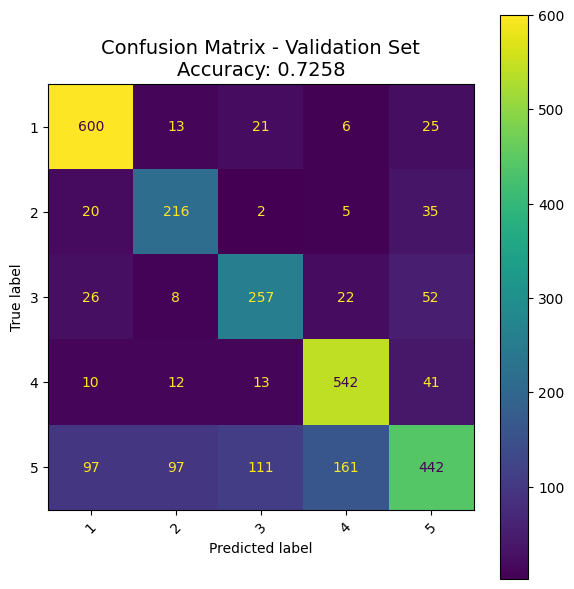

💾 Detailed predictions saved: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/predictions_validation.csv

SUMMARY
Dataset: Validation
Total samples: 2834
Valid predictions: 2834 (100.0%)
Accuracy on valid predictions: 0.7258
Correct predictions: 2057/2834

EVALUATING TEST SET
Processing 2770 samples...
  Progress: 16/2770 samples processed
  Progress: 176/2770 samples processed
  Progress: 336/2770 samples processed
  Progress: 496/2770 samples processed
  Progress: 656/2770 samples processed
  Progress: 816/2770 samples processed
  Progress: 976/2770 samples processed
  Progress: 1136/2770 samples processed
  Progress: 1296/2770 samples processed
  Progress: 1456/2770 samples processed
  Progress: 1616/2770 samples processed
  Progress: 1776/2770 samples processed
  Progress: 1936/2770 samples processed
  Progress: 2096/2770 samples processed
  Progress: 2256/2770 samples processed
  Progress: 2416/2770 samples processed
  Progress: 2576/2770 samples processed
  Progress: 27

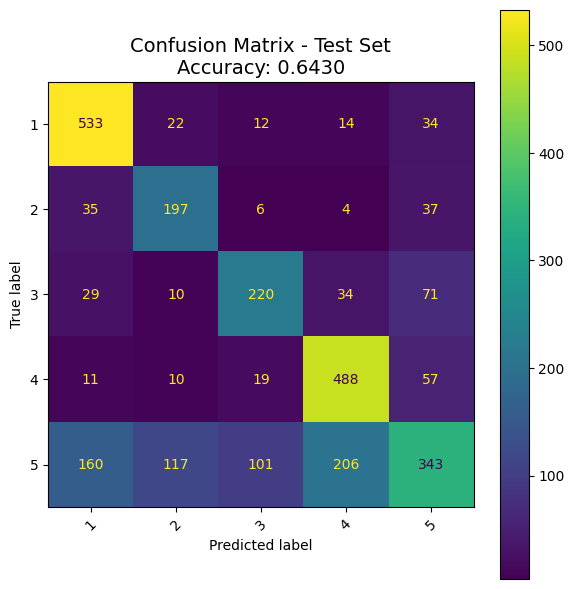

💾 Detailed predictions saved: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/predictions_test.csv

SUMMARY
Dataset: Test
Total samples: 2770
Valid predictions: 2770 (100.0%)
Accuracy on valid predictions: 0.6430
Correct predictions: 1781/2770

✅ EVALUATION COMPLETE!

📊 Final Results:
  Validation Accuracy: 0.7258
  Test Accuracy: 0.6430

📁 Files saved in: /content/gdrive/MyDrive/Colab Notebooks/d266/FinalProject/
  ✓ confusion_matrix_validation.png
  ✓ confusion_matrix_test.png
  ✓ predictions_validation.csv
  ✓ predictions_test.csv


In [ ]:

# RUN EVALUATION

print("\n" + "="*70)
print("STARTING EVALUATION")
print("="*70)

# Evaluate validation set
val_results = evaluate_dataset(
    model=model,
    tokenizer=tokenizer,
    dataset=tokenized_val,
    dataset_name="Validation",
    label_names=label_names,
    device=device,
    batch_size=16
)

# Evaluate test set
test_results = evaluate_dataset(
    model=model,
    tokenizer=tokenizer,
    dataset=tokenized_test,
    dataset_name="Test",
    label_names=label_names,
    device=device,
    batch_size=16
)


# FINAL SUMMARY

print("\n" + "="*70)
print("EVALUATION COMPLETE!")
print("="*70)

if val_results and test_results:
    print(f"\n Final Results:")
    print(f"  Validation Accuracy: {val_results['accuracy']:.4f}")
    print(f"  Test Accuracy: {test_results['accuracy']:.4f}")
    print(f"\n Files saved in: {base_dir}")
    print("  confusion_matrix_validation.png")
    print("  confusion_matrix_test.png")
    print("  predictions_validation.csv")
    print("  predictions_test.csv")
else:
    print("\nEvaluation encountered errors. Check the output above for details.")

# End of File